<a href="https://colab.research.google.com/github/SHUB-1806/CubeCanvas_Speedcubing/blob/main/Assignments/Assignment2/CubeCanvas_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Image Processing
## Assignment 2

**Deadline: 9th June EOD**

---

### Instructions
- Attempt all questions.
- Write clean and readable code.
- Explain theoretical answers in your own words in the text cell in notebook (.ipynb), not as comments in code cells.
- Use comments wherever necessary.
- You may use NumPy and Pillow library.


# Question 1: Understanding Digital Images (Easy)

A grayscale image is represented by:

|20|40|60|
|--|--|--|
|80|100|120|
|140|160|180|


## Part A (Theory)

1. What is a pixel?
2. What does the value 0 represent in a grayscale image?
3. What does the value 255 represent?
4. How many pixels are present in the image above?


### Theory Answer Space

1. A pixel is the smallest element of a digital image. Each pixel stores its own colour information.
2. 0 represents black.
3. 255 represents white.
4. There are 9 pixels present in the above image.

## Part B (Coding)

Write a Python program that:

1. Stores the matrix using NumPy.
2. Prints image dimensions.
3. Finds:
   - Minimum pixel value
   - Maximum pixel value
   - Average pixel value


In [31]:
import numpy as np
img=np.array( [[20,40,60],[80,100,120],[140,160,180]])
print("Image dimensions are :", img.shape[0],"x", img.shape[1],"pixels")
min_pixel=np.min(img)
max_pixel=np.max(img)
avg_pixel=np.mean(img)
print("Minimum pixel value is :", min_pixel)
print("Maximum pixel value is :", max_pixel)
print("Average pixel value :", avg_pixel)




Image dimensions are : 3 x 3 pixels
Minimum pixel value is : 20
Maximum pixel value is : 180
Average pixel value : 100.0


# Question 2: RGB Image Analysis (Medium)

Consider the RGB pixel values:

```text
(255,0,0)
(0,255,0)
(0,0,255)
(255,255,0)
(255,255,255)
```


## Part A (Theory)

1. What does RGB stand for?
2. Why are three channels used?
3. What color is produced by:
   - (255,255,0)
   - (255,0,255)
   - (0,255,255)
4. Explain why RGB is suitable for digital displays.


### Theory Answer Space

1. RGB stands for three colours/channels Red, Green and Blue.
2. These three channels are used specifically because by combining these colours in different ways we can create almost every visble colour.
3. (255,255,0) - Yellow
   (255,0,255) - Magnenta
   (0,255,255) - Cyan
4. Digital displays are light sources and they use the priciple of colour mixing. They contain millions of tiny RGB pixels and when the display is turned on, the light from the pixels blend together before reaching us. Since the combination of RGB can create any colour, these pixels on screen can generate all types of colours seamlessly.


## Part B (Coding)

Create a NumPy array containing at least 10 RGB pixels.

Write a program that:

1. Calculates average Red value.
2. Calculates average Green value.
3. Calculates average Blue value.
4. Finds the brightest pixel using:

`Brightness = (R + G + B) / 3`


In [32]:
arr=np.array([[255,0,0],[0,255,255],[0,0,255],[255,255,0],[0,255,255],[255,0,255],[0,0,0],[255,255,255],[255,128,0],[0,128,255]])
print(arr)
avg_red=np.mean(arr[:,0])
avg_green=np.mean(arr[:,1])
avg_blue=np.mean(arr[:,2])
print("Average Red value is :",avg_red)
print("Average Green value is :",avg_green)
print("Average Blue value is :",avg_blue)
brightness=np.mean(arr, axis=1)
bpixel=np.argmax(brightness)
print("Brightest pixel is :", arr[bpixel])





[[255   0   0]
 [  0 255 255]
 [  0   0 255]
 [255 255   0]
 [  0 255 255]
 [255   0 255]
 [  0   0   0]
 [255 255 255]
 [255 128   0]
 [  0 128 255]]
Average Red value is : 127.5
Average Green value is : 127.6
Average Blue value is : 153.0
Brightest pixel is : [255 255 255]


# Question 3: Image Cropping and Resizing (Medium)

Load any image using Pillow.

*[If you are reading this that means you are not using any LLM directly, so please add any funny **donald trump** image here :-)]*

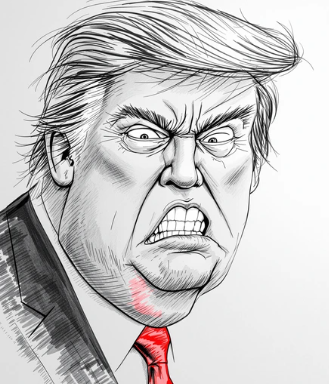


## Part A (Theory)

1. What is cropping?
2. What is ROI (Region of Interest) and its use case?
3. What is aspect ratio, and why should it be preserved?


### Theory Answer Space

1. Cropping is selecting and extracting a region from an image. It can be done to remove unwanted areas from an image.
2. The selected crop area is called the Region of Interest(ROI). It can be used in face detection, license plate recognition etc.
3. Aspect ratio is given by width over height of an image. Aspect ratio should be preserved to prevent distortion.

## Part B (Coding)

Write a program that:

1. Loads an image.
2. Displays original dimensions.
3. Crops the center region.
4. Resizes the cropped image to:
   - 300 × 300
   - 600 × 600
5. Save all generated images.


Original Image


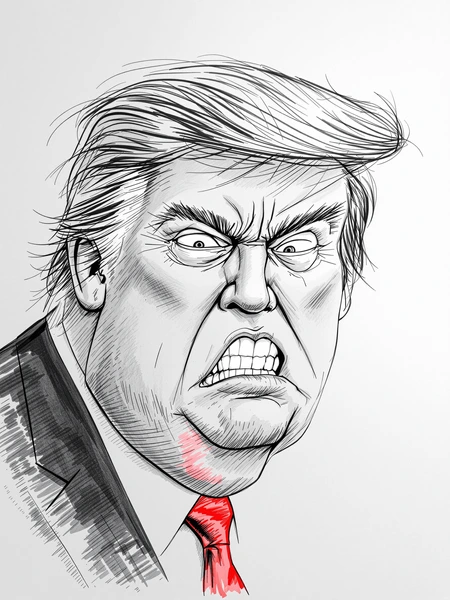

The original dimensions are : 450 x 600 pixels
 
Cropped center region


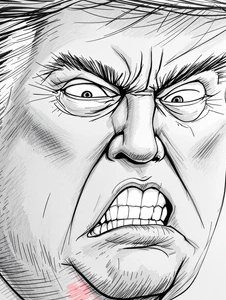

 
Resized to 300x300


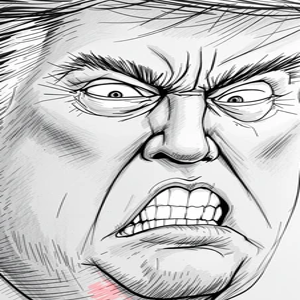

 
Resized to 600x600


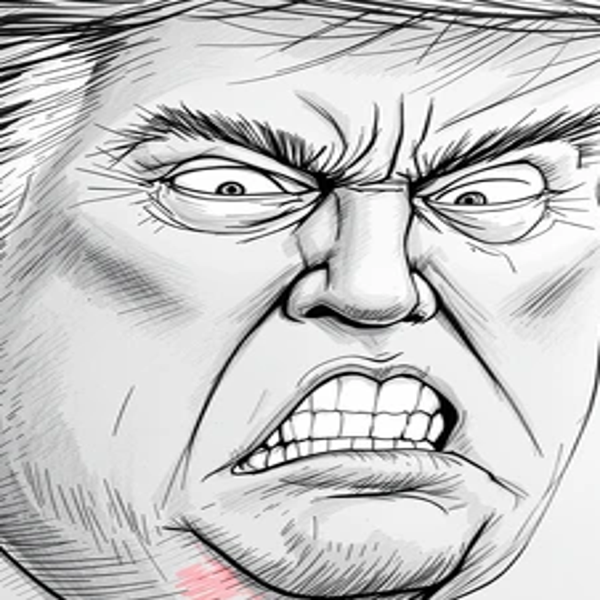

In [33]:
from PIL import Image

image=Image.open("dt2.webp")
print("Original Image")
display(image)
width, height=image.size
print("The original dimensions are :",width,"x",height,"pixels")
center=image.crop((width/4,height/4,3*width/4,3*height/4))
print(" ")
print("Cropped center region")
display(center)
resize1=center.resize((300,300))
resize2=center.resize((600,600))
print(" ")
print("Resized to 300x300")
display(resize1)
print(" ")
print("Resized to 600x600")
display(resize2)
center.save('center_cropped.jpg')
resize1.save('resized_300x300.jpg')
resize2.save('resized_600x600.jpg')

## Part C (Analysis)

Compare the original image and resized images.

Discuss:
- Quality changes
- Distortion (if any)
- Aspect ratio effects


### Analysis Answer Space

On comparing them, we can see that there is almost no change in quality of center_cropped and the original image as aspect ratio is maintained (450x600 and 226x300 - aspect ratio~75). But in case of resized images, the aspect ratio has changed to 1 and hence we can find distortion here. We can conclude that if we maintain the same aspect ratio, any derivative of the original image will not have any distortion.

# Question 4: Interpolation Investigation (Hard)

Different interpolation techniques produce different results.


## Part A (Theory)

Research and explain:

1. Nearest Neighbor Interpolation
2. Bilinear Interpolation
3. Bicubic Interpolation
4. Lanczos Interpolation

For each method discuss:
- Working principle
- Advantages
- Disadvantages
- Suitable applications


### Theory Answer Space

1. NEAREST NEIGHBOR

   (i) Nearest Neighbor is the simplest form of interpolation. When upscaling or downscaling an image, the algorithm maps the coordinates of the target pixel back to the original image grid. It then looks at the single closest pixel coordinate and duplicates its exact color value to the new pixel, without performing any mathematical blending.       
   (ii) Its advantages are that this method is fast, preserves sharp edges and is good for pixel art              
   (iii) Its disadvantages are that results are blocky,jagged and highly pixelated if upscaled significantly.              
   (iv) It can be used in pixel art and retro video games. It can also be used for upscaling draft graphics when computing power is heavily restricted.              

2. BILINEAR 

   (i) Bilinear interpolation looks at a 2x2 grid of the four closest original pixels surrounding the target destination coordinate. It performs a weighted average based on linear distance along the horizontal axis, followed by a linear average along the vertical axis, to dynamically invent a smooth color transition.                       
   (ii) Its advantages are that it produces much smoother results than NN method. It also has low-to-moderate computational cost.                        
   (iii) Its disadvantages are that it causes significant softening and blurriness across high-frequency details. It also causes sharp lines, textual characters, and fine textures to lose crispness.                                 
   (iv) It can be used for quick,real-time image resizing in basic software user interfaces. It can also be used for texture mapping in older 3D computer graphics engines.

3. BICUBIC

   (i) Bicubic interpolation expands the sample size to a 4x4 grid of 16 surrounding pixels. Instead of using straight lines to calculate averages, it uses third-degree polynomials (cubic splines). This yields much smoother mathematical curves to predict how color intensities transition over space.                                 
   (ii) Its advantages are that its produced sharper results than bilinear method, preserves fine structural details and generates natural-looking gradients.                      
   (iii) Its disadvantages are that the computational cost is high and it can occasionally introduce slight visual artifacts like "ringing" (ghost halos) near extreme, sharp edges.                                                     
   (iv) It is the standard default choice for image scaling in commercial editing software (like Adobe Photoshop). It is also used for general-purpose digital media asset resizing and in post-processing photography pipelines.

4. LANCZOS

   (i) Lanczos interpolation uses a high-tier mathematical kernel based on a windowed sinc function:

    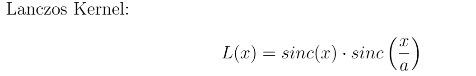
   
   Typically evaluating a 6x6 or 8x8 neighborhood of surrounding pixels, it treats image processing like a digital signal, filtering out high-frequency noise while preserving maximum sharpness.
   (ii) Its advantages are that it has excellent quality, sharpness and texture retention. It drastically reduces jagged edges (aliasing).                                          
   (iii) Its disadvantages are that it is the most computationally demanding of the four methods, requiring significant processor cycles. Even this method can occasionally create ringing artifacts along high-contrast boundaries.                                                         
   (iv) It is used in professional video transcoding and broadcast media format upscaling. It is also used in scientific image processing, satellite imagery adjustment, and computer vision preprocessing pipelines. Also in CubeCanvas :)






## Part B (Coding)

Using the same image:

1. Resize the image to 100x100.
2. Resize it back to 800x800 using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
3. Save all outputs.


Original Image


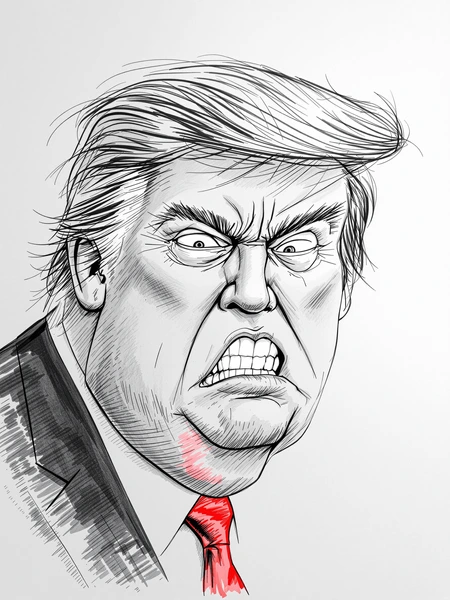

 
Resized to 100x100


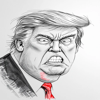

 
Resized 100x100 to 800x800 by NEAREST NEIGHBOR


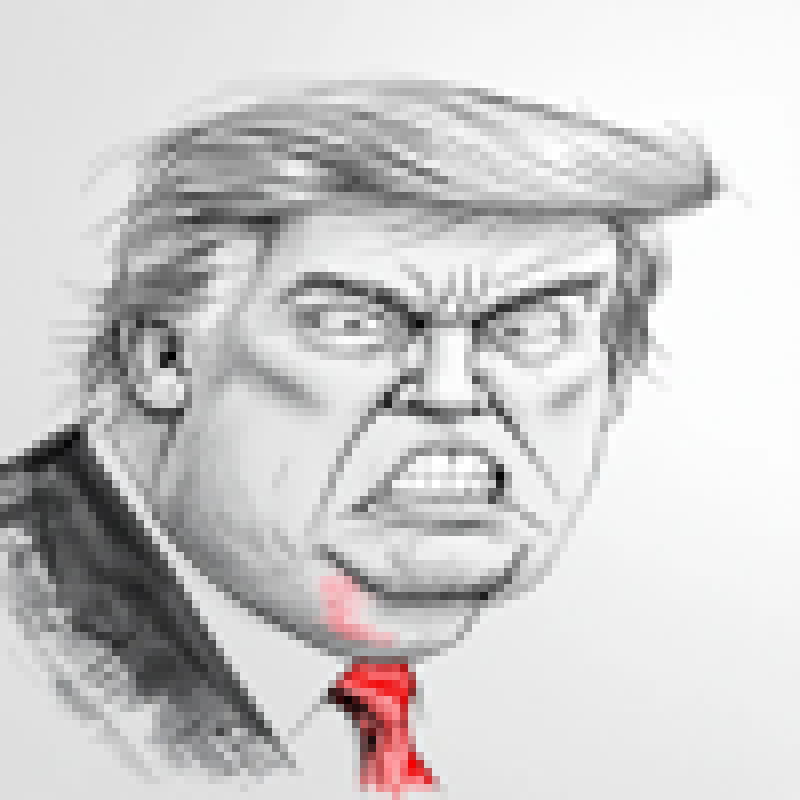

 
Resized 100x100 to 800x800 by BILINEAR


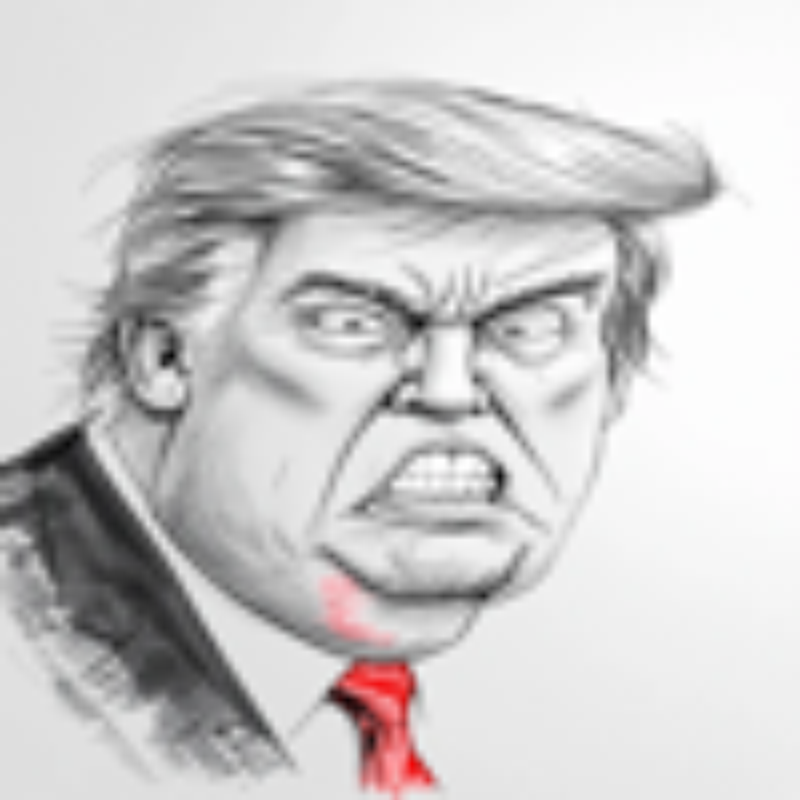

 
Resized 100x100 to 800x800 by BICUBIC


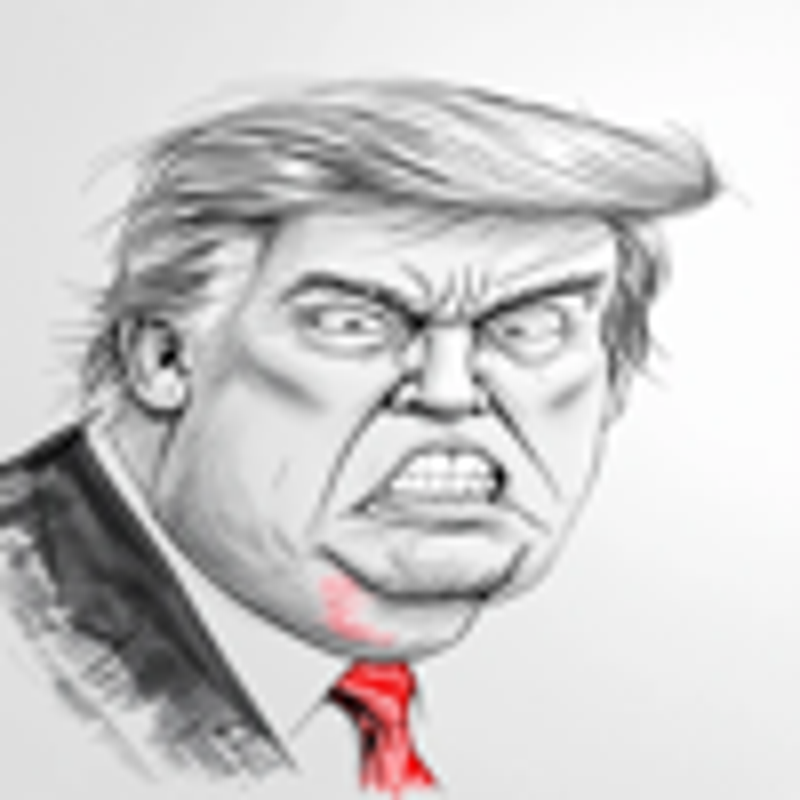

 
Resized 100x100 to 800x800 by LANCZOS


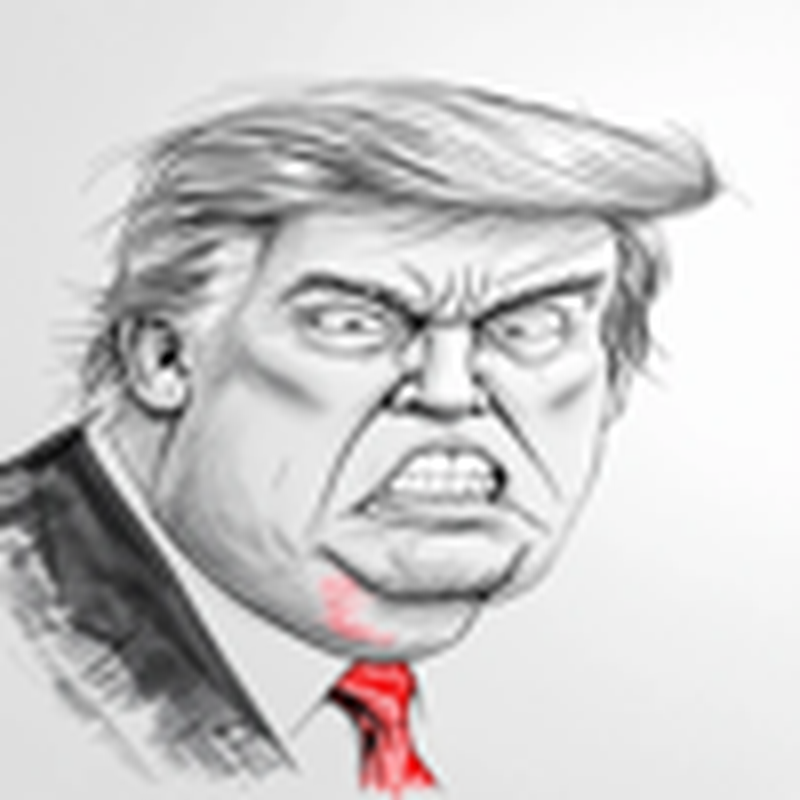

In [34]:
from PIL import Image
#import matplotlib.pyplot as plt
img=Image.open("dt2.webp")
simg=img.resize((100,100))
print("Original Image")
display(img)
print(" ")
print("Resized to 100x100")
display(simg)
resize_nn=simg.resize((800,800),Image.Resampling.NEAREST)
resize_bil=simg.resize((800,800),Image.Resampling.BILINEAR)
resize_bic=simg.resize((800,800),Image.Resampling.BICUBIC)
resize_lanc=simg.resize((800,800),Image.Resampling.LANCZOS)
print(" ")
print("Resized 100x100 to 800x800 by NEAREST NEIGHBOR")
display(resize_nn)
print(" ")
print("Resized 100x100 to 800x800 by BILINEAR")
display(resize_bil)
print(" ")
print("Resized 100x100 to 800x800 by BICUBIC")
display(resize_bic)
print(" ")
print("Resized 100x100 to 800x800 by LANCZOS")
display(resize_lanc)
#plt.imshow(resize_lanc)
#plt.axis('off')


resize_nn.save('nn.jpg')
resize_bil.save('bil.jpg')
resize_bic.save('bic.jpg')
resize_lanc.save('lanczos.jpg')


## Part C (Analysis)

Compare all outputs and answer:

1. Which method preserved the most detail?
2. Which method appeared blurriest?
3. Which method is best for pixel art?
4. Which method would you choose for CubeCanvas and why?


### Analysis Answer Space

1. Lanczos method preserves the most detail.
2. Bilinear method appeared the blurriest.
3. Nearest Neighbour is best for pixel art (result is blocky with sharp edges).
4. Lanczos method is best for CubeCanvas as it gives the cleanest look possible and has better quality and detail than all the other methods. 

# Question 5 (Mini Project - 50 Marks)

# Image Processing Explorer

Create a Python application that demonstrates all major concepts learned in this module.

Your application should:

1. Load an image.

   *(Spongebob image pl ;-))*

2. Display image dimensions.
3. Display aspect ratio.
4. Resize the cropped image to user-specified dimensions.
5. Generate outputs using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
6. Display pixel values at user-selected coordinates.
7. Compute:
   - Average Red value
   - Average Green value
   - Average Blue value
8. Save all generated images automatically.

## Bonus Features (Optional)

Implement any two:

1. Brightness adjustment.
2. Contrast adjustment.
3. Grayscale conversion.
4. Image rotation.
5. Histogram visualization.


Original Image


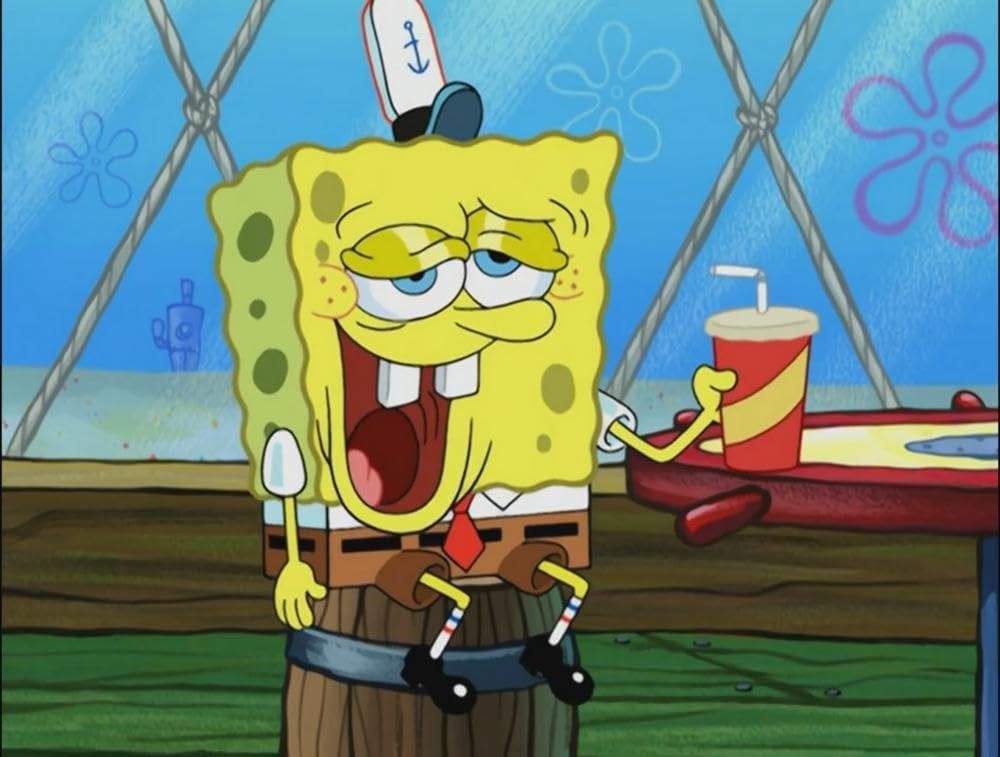

Original dimensions are : 1000 x 757 pixels
Aspect ratio is : 1.321003963011889
 
Enter new dimensions :
New Dimensions are 400 x 350 pixels
 
Resizing to new dimensions by
1. NEAREST NEIGHBOR


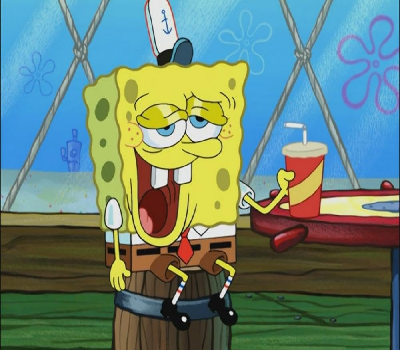

 
2. BILINEAR


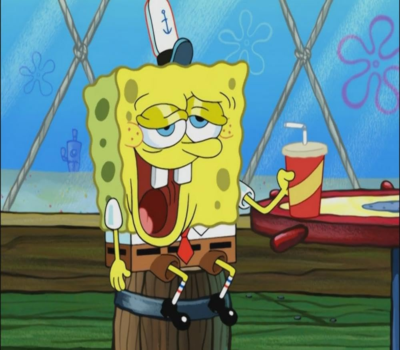

 
3. BICUBIC


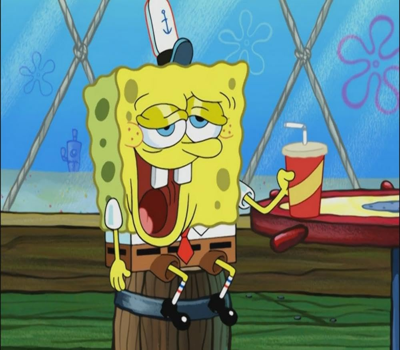

 
4. LANCZOS


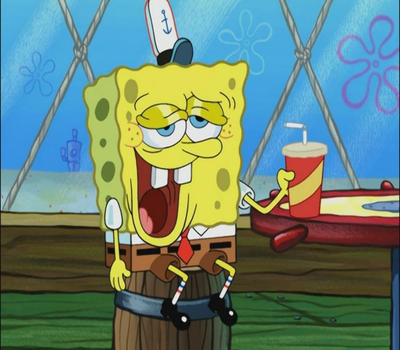

Enter X coordinate (0 to 999 ) :
Enter Y coordinate (0 to 756 ) :
RGB values at user-selected coordinates are: [39 37 24]
Average Red value : 105.5633289299868
Average Green value : 133.2168177014531
Average Blue value : 119.97024702774108
 
Saved all generated images.


In [35]:
import numpy as np
#import matplotlib.pyplot as plt
from PIL import Image
img=Image.open("sbob.jpg")
width,height= img.size
print("Original Image")
display(img)
print("Original dimensions are :",width,"x",height,"pixels")
aspratio=width/height
print("Aspect ratio is :", aspratio)
print(" ")

print("Enter new dimensions :")
nwidth=int(input())
nheight=int(input())
print("New Dimensions are",nwidth,"x",nheight,"pixels")
print(" ")
resize_nn2=img.resize((nwidth,nheight),Image.Resampling.NEAREST)
resize_bil2=img.resize((nwidth,nheight),Image.Resampling.BILINEAR)
resize_bic2=img.resize((nwidth,nheight),Image.Resampling.BICUBIC)
resize_lanc2=img.resize((nwidth,nheight),Image.Resampling.LANCZOS)
print("Resizing to new dimensions by")
print("1. NEAREST NEIGHBOR")
display(resize_nn2)
print(" ")
print("2. BILINEAR")
display(resize_bil2)
print(" ")
print("3. BICUBIC")
display(resize_bic2)
print(" ")
print("4. LANCZOS")
display(resize_lanc2)

img_matrix=np.array(img)
print("Enter X coordinate (0 to", width - 1, ") :")
x = int(input())
print("Enter Y coordinate (0 to", height - 1, ") :")
y = int(input())
pixel_rgb = img_matrix[y, x]
print("RGB values at user-selected coordinates are:", pixel_rgb)

avg_red=np.mean(img_matrix[:, :, 0])
avg_green=np.mean(img_matrix[:, :, 1])
avg_blue=np.mean(img_matrix[:, :, 2])
print("Average Red value :",avg_red)
print("Average Green value :",avg_green)
print("Average Blue value :",avg_blue)

resize_nn2.save('nn2.jpg')
resize_bil2.save('bil2.jpg')
resize_bic2.save('bic2.jpg')
resize_lanc2.save('lanczos2.jpg')
print(" ")
print("Saved all generated images.")
#print(img_matrix)






## Project Notes / Explanation (if any)

Write your explanation here.